# GPT2 trained weights distributions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import torch
from transformers import AutoModelForCausalLM

In [2]:
# load SMALL pretrained GPT-2 model and tokenizer
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2')

## Distribution of attention and MLP weights

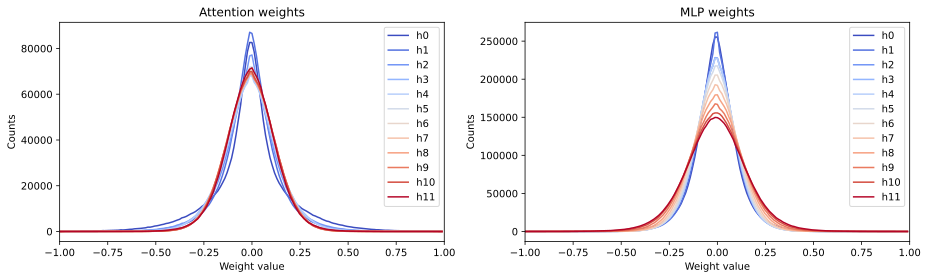

In [3]:
_, axs = plt.subplots(1,2,figsize=(13,4))

bins = np.linspace(-1,1,171)
colors = plt.cm.coolwarm(np.linspace(0,1,len(gpt2.transformer.h)))

for hidx in range(len(gpt2.transformer.h)):
    # attention weights
    y, x = np.histogram(gpt2.transformer.h[hidx].attn.c_attn.weight.detach(), bins=bins)
    axs[0].plot(x[:-1], y, color=colors[hidx], label=f'h{hidx}')

    # MLP weights
    allMLP = torch.concatenate((gpt2.transformer.h[hidx].mlp.c_fc.weight.flatten(),
                               gpt2.transformer.h[hidx].mlp.c_proj.weight.flatten()))
    y, x = np.histogram(allMLP.detach(), bins=bins)
    axs[1].plot(x[:-1], y, color=colors[hidx], label=f'h{hidx}')

for a in axs:
    a.legend(fontsize=10)
    a.set(xlim=bins[[0,-1]], xlabel='Weight value', ylabel='Counts')

axs[0].set_title('Attention weights')
axs[1].set_title('MLP weights')

plt.tight_layout()
plt.show()

## Separately for Q,K and V matrices

In [4]:
# q,k,v are each of size n_emb X n_emb, and are concatenated into c_attn
gpt2.transformer.h[0].attn.c_attn.weight.shape#[1]/3

torch.Size([768, 2304])

In [5]:
# example splitting the matrix into q, k, and v
n_emb = gpt2.transformer.wte.weight.shape[1]
q_weight, k_weight, v_weight = torch.split(gpt2.transformer.h[0].attn.c_attn.weight, n_emb, dim=1)

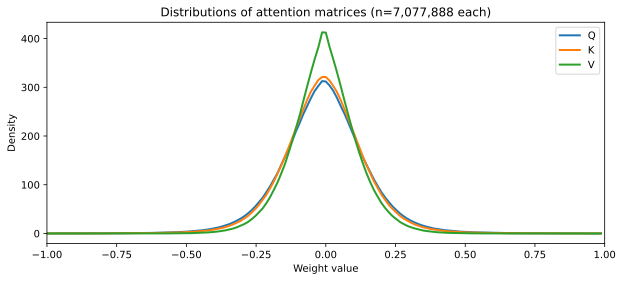

In [6]:
bins = np.linspace(-1,1,151)

# initialize
allq = np.array([])
allk = np.array([])
allv = np.array([])

n_emb = gpt2.transformer.wte.weight.shape[1]

# loop over all transformers and get their weights
for hidx in range(len(gpt2.transformer.h)):
    # split into matrices
    q,k,v = torch.split(gpt2.transformer.h[hidx].attn.c_attn.weight,n_emb,dim=1)

    # add to the pile o' numbers
    allq = np.concatenate((allq,q.detach().flatten().numpy()),axis=0)
    allk = np.concatenate((allk,k.detach().flatten().numpy()),axis=0)
    allv = np.concatenate((allv,v.detach().flatten().numpy()),axis=0)


# get histogram bins
yq, xq = np.histogram(allq, bins=bins, density=True)
yk, xk = np.histogram(allk, bins=bins, density=True)
yv, xv = np.histogram(allv, bins=bins, density=True)

# and plot
plt.figure(figsize=(10,4))
plt.plot(xq[:-1], 100*yq, linewidth=2, label='Q')
plt.plot(xk[:-1], 100*yk, linewidth=2, label='K')
plt.plot(xv[:-1], 100*yv, linewidth=2, label='V')

plt.legend()
plt.gca().set(xlim=bins[[0,-1]],
              xlabel='Weight value',
              ylabel='Density',
              title=f'Distributions of attention matrices (n={len(allq):,} each)')

plt.show()